#### Figure 5A. Focused latent space with highlighted sequences 

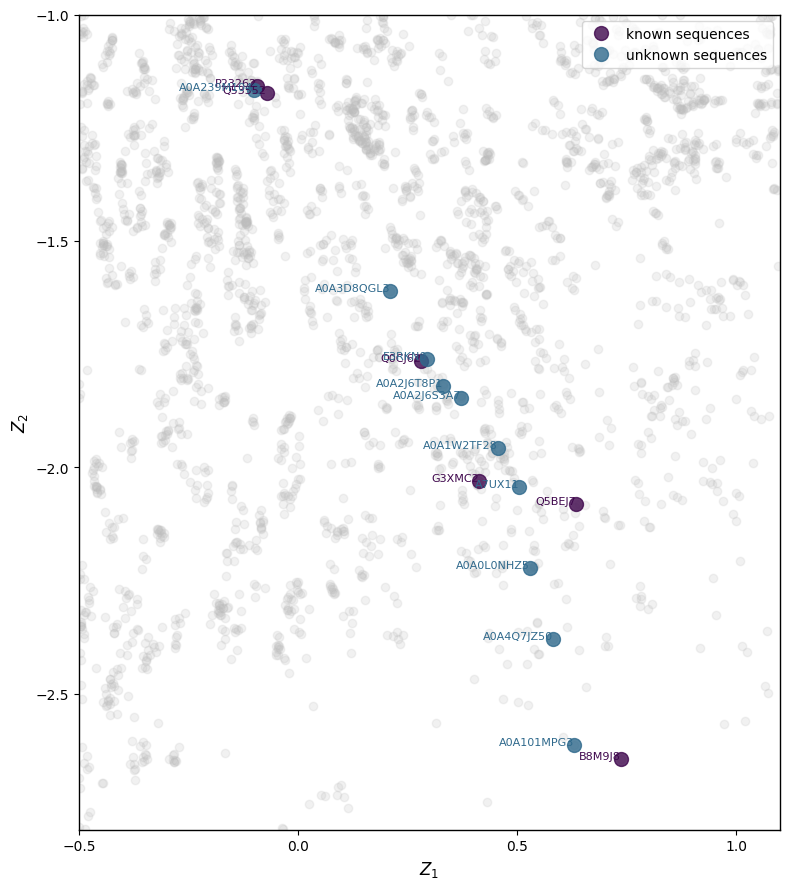

In [21]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Load the latent space representation
with open("../models/FDMO/NoCV_latent_space_d2_layer4_w0.0005_b256_l0.0005_beta1_1000epoch_seed19.pkl", 'rb') as file_handle:
    data = pickle.load(file_handle)
key = data['key']
mu = data['mu']
sigma = data['sigma']
t_key = data['t_key']
t_mu = data['t_mu']
t_sigma = data['t_sigma']

# Combine training and test data
combined_key = key + t_key
combined_mu = np.vstack((mu, t_mu))
combined_sigma = np.vstack((sigma, t_sigma))
key2mu_dict = {k: m for k, m in zip(combined_key, combined_mu)}

# Define sequences to highlight
known = ['B8M9J8', 'Q5BEJ7', 'G3XMC2', 'Q0CJ62', 'P23262', 'Q53552']
unknown = ['A0A101MPG3', 'A0A4Q7JZ50', 'A0A0L0NHZ5', 'A7UX11', 'A0A1W2TF28', 
           'A0A2J6S3A7', 'A0A2J6T8P1', 'A0A3D8QGL3', 'E3RKN0', 'A0A239M104']

# Set up custom colors
custom_gray = (189/255, 189/255, 189/255)
custom_known_color = (63/255, 7/255, 77/255)  # Red for known sequences
custom_unknown_color = (47/255, 105/255, 140/255)  # Green for unknown sequences
custom_frame = (189/255, 189/255, 189/255)

# Define the region to focus on (adjust as needed)
focus_x_range = (-0.5, 1.1)
focus_y_range = (-2.8, -1.0)

def plot_filtered_data(ax, data, keys, keys_to_check, color, label, annotate=False):
    """Filter, plot, and optionally annotate data based on specific keys."""
    indices = [idx for idx, key_val in enumerate(keys) if key_val in keys_to_check]
    filtered_mu = data[indices]
    ax.plot(filtered_mu[:, 0], filtered_mu[:, 1], 'o', color=color, alpha=0.8, markersize=10, label=label)
    
    # Annotate each point if specified
    if annotate:
        for idx in indices:
            ax.text(data[idx, 0], data[idx, 1], keys[idx], fontsize=8, color=color, ha='right')

# Plot with focus on a local region and highlight known and unknown sequences
fig, ax = plt.subplots(figsize=(8, 9))

# Plot training data within the focus range
filtered_mu = mu[(mu[:, 0] >= focus_x_range[0]) & (mu[:, 0] <= focus_x_range[1]) &
                 (mu[:, 1] >= focus_y_range[0]) & (mu[:, 1] <= focus_y_range[1])]
ax.plot(filtered_mu[:, 0], filtered_mu[:, 1], 'o', color=custom_gray, alpha=0.2, markersize=6)

# Plot and annotate known sequences in the focused region
plot_filtered_data(ax, combined_mu, combined_key, known, custom_known_color, 'known sequences', annotate=True)

# Plot and annotate unknown sequences in the focused region
plot_filtered_data(ax, combined_mu, combined_key, unknown, custom_unknown_color, 'unknown sequences', annotate=True)

# Set axis limits to the focused region
ax.set_xlim(focus_x_range)
ax.set_ylim(focus_y_range)

# Axis labels
ax.set_xlabel("$Z_1$", fontsize=12)
ax.set_ylabel("$Z_2$", fontsize=12)

# Set specific tick positions for x and y axes
ax.set_xticks(np.arange(-0.5, 1.5, 0.5))
ax.set_yticks([-2.5, -2.0, -1.5, -1.0])

# Adjust the border line width
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(1)  # Set the desired width (e.g., 2)

# Hide the tick labels if desired
ax.tick_params(axis='both', which='both', labelbottom=True, labelleft=True)

# Legend
ax.legend(loc='upper right')

# Layout adjustment
fig.tight_layout()

# Save the focused figure
fig.savefig('../results/Figure5/PF01494_latent_space_focused_with_labels.png', dpi=300, format='png')

plt.show()



#### Figure 5A. Focused latent space with highlighted sequences  (color code selectivity)

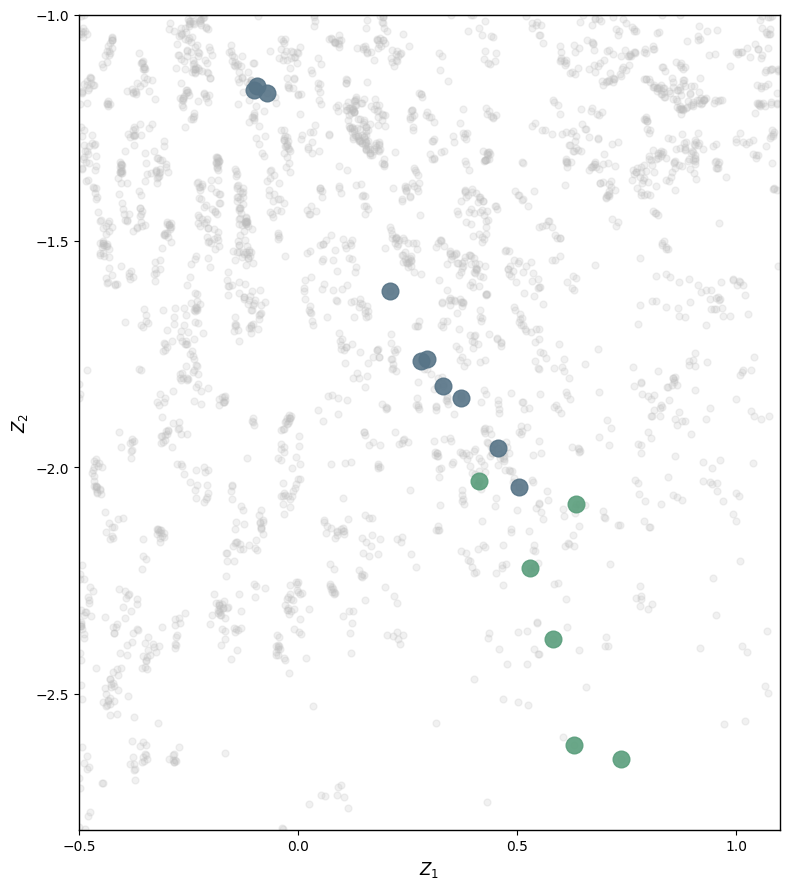

In [22]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Load the latent space representation
with open("../models/FDMO/NoCV_latent_space_d2_layer4_w0.0005_b256_l0.0005_beta1_1000epoch_seed19.pkl", 'rb') as file_handle:
    data = pickle.load(file_handle)
key = data['key']
mu = data['mu']
sigma = data['sigma']
t_key = data['t_key']
t_mu = data['t_mu']
t_sigma = data['t_sigma']

# Combine training and test data
combined_key = key + t_key
combined_mu = np.vstack((mu, t_mu))
combined_sigma = np.vstack((sigma, t_sigma))
key2mu_dict = {k: m for k, m in zip(combined_key, combined_mu)}

# Define sequences to highlight
known = ['B8M9J8', 'Q5BEJ7', 'G3XMC2', 'Q0CJ62', 'P23262', 'Q53552']
unknown = ['A0A101MPG3', 'A0A4Q7JZ50', 'A0A0L0NHZ5', 'A7UX11', 'A0A1W2TF28', 
           'A0A2J6S3A7', 'A0A2J6T8P1', 'A0A3D8QGL3', 'E3RKN0', 'A0A239M104']
C1 = ['A7UX11', 'A0A1W2TF28', 'A0A2J6S3A7', 'A0A2J6T8P1', 'A0A3D8QGL3', 
      'E3RKN0', 'A0A239M104', 'Q0CJ62', 'P23262', 'Q53552']
C3 = ['B8M9J8', 'Q5BEJ7', 'G3XMC2', 'A0A101MPG3', 'A0A4Q7JZ50', 'A0A0L0NHZ5']

# Set up custom colors
custom_gray = (189/255, 189/255, 189/255)
custom_known_color = (63/255, 7/255, 77/255)  # Red for known sequences
custom_unknown_color = (47/255, 105/255, 140/255)  # Green for unknown sequences
custom_frame = (189/255, 189/255, 189/255)
custom_C1 = (87/255, 116/255, 135/255)
custom_C3 = (90/255, 158/255, 124/255)

# Define the region to focus on (adjust as needed)
focus_x_range = (-0.5, 1.1)
focus_y_range = (-2.8, -1.0)

def plot_filtered_data(ax, data, keys, keys_to_check, color, label, annotate=False):
    """Filter, plot, and optionally annotate data based on specific keys."""
    indices = [idx for idx, key_val in enumerate(keys) if key_val in keys_to_check]
    filtered_mu = data[indices]
    ax.plot(filtered_mu[:, 0], filtered_mu[:, 1], 'o', color=color, alpha=0.9, markersize=12, label=label)
    
    # Annotate each point if specified
    if annotate:
        for idx in indices:
            ax.text(data[idx, 0], data[idx, 1], keys[idx], fontsize=8, color=color, ha='right')

# Plot with focus on a local region and highlight known and unknown sequences
fig, ax = plt.subplots(figsize=(8, 9))

# Plot training data within the focus range
filtered_mu = mu[(mu[:, 0] >= focus_x_range[0]) & (mu[:, 0] <= focus_x_range[1]) &
                 (mu[:, 1] >= focus_y_range[0]) & (mu[:, 1] <= focus_y_range[1])]
ax.plot(filtered_mu[:, 0], filtered_mu[:, 1], 'o', color=custom_gray, alpha=0.2, markersize=5)

# Plot and annotate known sequences in the focused region
plot_filtered_data(ax, combined_mu, combined_key, C1, custom_C1, 'C1-selectivity', annotate=False)

# Plot and annotate unknown sequences in the focused region
plot_filtered_data(ax, combined_mu, combined_key, C3, custom_C3, 'C3-selectivity', annotate=False)

# Set axis limits to the focused region
ax.set_xlim(focus_x_range)
ax.set_ylim(focus_y_range)

# Axis labels
ax.set_xlabel("$Z_1$", fontsize=12)
ax.set_ylabel("$Z_2$", fontsize=12)

# Set specific tick positions for x and y axes
ax.set_xticks(np.arange(-0.5, 1.5, 0.5))
ax.set_yticks([-2.5, -2.0, -1.5, -1.0])

# Adjust the border line width
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(1)  # Set the desired width (e.g., 2)

# Hide the tick labels if desired
ax.tick_params(axis='both', which='both', labelbottom=True, labelleft=True)

# Legend
# ax.legend(loc='upper right')

# Layout adjustment
fig.tight_layout()

# Save the focused figure
fig.savefig('../results/Figure5/PF01494_latent_space_focused_color.png', dpi=300, format='png')

plt.show()

#### Sampling enzymes

In [25]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the latent space representation
with open("../models/FDMO/NoCV_latent_space_d2_layer4_w0.0005_b256_l0.0005_beta1_1000epoch_seed19.pkl", 'rb') as file_handle:
    data = pickle.load(file_handle)

key = data['key']
mu = data['mu']
sigma = data['sigma']

key2mu_dict = {k: m for k, m in zip(key, mu)}

def sample_all_distances_along_trajectory(start_key, end_key, key2mu, all_keys, all_mu, num_steps=11):
    """
    Calculates the coordinate points along a trajectory vector and computes 
    the distance from each point to ALL sequences in the database.
    """
    if start_key not in key2mu or end_key not in key2mu:
        raise ValueError(f"Ensure both {start_key} and {end_key} exist in the latent space dictionary.")
        
    start_coords = key2mu[start_key]
    end_coords = key2mu[end_key]
    
    # Generate 11 points: index 0 is start (TropB), index 10 is end (AtA), 1-9 are the intermediates
    t_values = np.linspace(0, 1, num_steps)
    path_points = np.array([start_coords + t * (end_coords - start_coords) for t in t_values])
    
    all_records = []
    
    # Iterate through each coordinate point on the vector trajectory
    for step_idx, step_coord in enumerate(path_points):
        # Calculate Euclidean distance from the current coordinate to ALL sequences at once
        distances = np.linalg.norm(all_mu - step_coord, axis=1)
        
        # Log data for every sequence relative to this specific coordinate step
        for idx, seq_key in enumerate(all_keys):
            all_records.append({
                "Coordinate_Step": step_idx,         # 0 (TropB) to 10 (AtA)
                "Progress_t": t_values[step_idx],    # 0.0 to 1.0
                "Coord_Z1": step_coord[0],
                "Coord_Z2": step_coord[1],
                "Sequence_ID": seq_key,
                "Seq_Z1": all_mu[idx, 0],
                "Seq_Z2": all_mu[idx, 1],
                "Distance_to_Coordinate": distances[idx]
            })
                
    df_all_distances = pd.DataFrame(all_records)
    return path_points, df_all_distances

# Run sampling pipeline
start_node = 'B8M9J8'  # TropB (Will be Step 0)
end_node = 'Q0CJ62'    # AtA (Will be Step 10)

# 11 steps gives exactly Step 0, Step 10, and 9 intermediate coordinates
STEPS = 11

trajectory_coords, distance_matrix_df = sample_all_distances_along_trajectory(
    start_key=start_node, 
    end_key=end_node, 
    key2mu=key2mu_dict, 
    all_keys=key, 
    all_mu=mu, 
    num_steps=STEPS
)

print(f"Calculation complete. Generated {STEPS} coordinates.")

# Sort the dataframe by step and then by distance (ascending)
distance_matrix_df_filtered = distance_matrix_df.sort_values(
    by=["Coordinate_Step", "Distance_to_Coordinate"]
)

# Group by each coordinate step and select the top 50 closest sequences
distance_matrix_df_filtered = distance_matrix_df_filtered.groupby("Coordinate_Step").head(50)

# Reset the index so the row numbers are sequential and clean
distance_matrix_df_filtered = distance_matrix_df_filtered.reset_index(drop=True)

# Export to Excel
output_file = "../results/Figure5/trajectory_top50_sequences_class.xlsx"
distance_matrix_df_filtered.to_excel(output_file, index=False)

print(f"Successfully saved the 50 closest sequences for all 11 coordinates to:")
print(output_file)

Calculation complete. Generated 11 coordinates.
Successfully saved the 50 closest sequences for all 11 coordinates to:
../results/Figure5/trajectory_top50_sequences_class.xlsx
